# Data Analysis for Biochemists SOLVED
## Combining itertools, numpy, pandas, and matplotlib

**Learning objectives:**
- Process experimental replicates using itertools
- Analyze enzyme kinetics with numpy
- Handle protein expression data with pandas
- Visualize dose-response curves with matplotlib
- Combine all tools for real biochemical analysis

# BIOCHEMISTRY DATA ANALYSIS WITH PYTHON
# Combining itertools, numpy, pandas, and matplotlib
# For intermediate-level biochemists

# Let me create this as a complete notebook structure

## Key Features for Biochemists:

### Example 1 (itertools focused):
- Drug combination screening design
- All possible pairs using `combinations()`
- Concentration matrix using `product()`
- Heatmap visualization of synergy

### Example 2 (numpy focused):
- Michaelis-Menten kinetics
- Lineweaver-Burk transformation
- Parameter estimation (Km, Vmax)
- Curve fitting with confidence

### Example 3 (pandas focused):
- Protein expression statistics
- Group comparisons (t-test)
- SEM calculation
- Publication-ready plots

### Example 4 (matplotlib focused):
- Dose-response curves
- IC50 calculation using Hill equation
- Semi-log plots (standard in pharmacology)
- Parameter interpretation

### Example 5 (integrated example):
- Time-course metabolomics
- AUC calculation
- Multiple metabolite tracking
- Error bars with SEM

## Data Sources:
- All data is **simulated** (no external files needed)
- Realistic patterns based on biochemical principles
- Reproducible with fixed random seeds

## Difficulty Progression:
1. **Example 1**: Basic combinations and heatmaps
2. **Example 2**: Mathematical modeling (intermediate)
3. **Example 3**: Statistical analysis (intermediate)
4. **Example 4**: Non-linear fitting (advanced)
5. **Example 5**: Multi-dimensional analysis (advanced)

Each example is **self-contained** with solutions in separate cells, making it perfect for teaching or self-study!

# The notebook contains:
- **5 complete examples** with solutions in separate cells
- **All libraries** (itertools, numpy, pandas, matplotlib, scipy)
- **Simulated data** (no external files needed)
- **Clear explanations** in markdown cells
- **Progressive difficulty** from basic to advanced
- **Biochemistry-focused** scenarios (enzyme kinetics, protein expression, dose-response, metabolomics)

Each example cell can be run independently, and all data is generated within the notebook so students don't need to download external files!

## Example 1: Processing All Possible Pairs of Experimental Conditions
**Scenario:** Comparing all treatment combinations in a drug screening experiment

*Libraries: itertools, pandas, matplotlib*

### Example 1 (itertools focused):
- Drug combination screening design
- All possible pairs using `combinations()`
- Concentration matrix using `product()`
- Heatmap visualization of synergy

In [1]:
# Load libraries
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
# Create experimental data
# 4 drugs at 3 concentrations each
drugs = ['Drug_A', 'Drug_B', 'Drug_C', 'Drug_D']
concentrations = [0.1, 1.0, 10.0]  # µM

# Generate all possible drug pairs for combination therapy
drug_pairs = list(itertools.combinations(drugs, 2))
print(f"All possible drug pairs for combination testing: {drug_pairs}")
print(f"Total pairs to test: {len(drug_pairs)}")

All possible drug pairs for combination testing: [('Drug_A', 'Drug_B'), ('Drug_A', 'Drug_C'), ('Drug_A', 'Drug_D'), ('Drug_B', 'Drug_C'), ('Drug_B', 'Drug_D'), ('Drug_C', 'Drug_D')]
Total pairs to test: 6


In [3]:
# Generate all concentration combinations for one drug pair
conc_A = [0.1, 1.0, 10.0]
conc_B = [0.1, 1.0, 10.0]

conc_combinations = list(itertools.product(conc_A, conc_B))
print("Concentration combinations to test (Drug_A, Drug_B):")
for combo in conc_combinations:
    print(f"  {combo[0]} µM + {combo[1]} µM")
print(f"\nTotal combinations to test: {len(conc_combinations)}")

Concentration combinations to test (Drug_A, Drug_B):
  0.1 µM + 0.1 µM
  0.1 µM + 1.0 µM
  0.1 µM + 10.0 µM
  1.0 µM + 0.1 µM
  1.0 µM + 1.0 µM
  1.0 µM + 10.0 µM
  10.0 µM + 0.1 µM
  10.0 µM + 1.0 µM
  10.0 µM + 10.0 µM

Total combinations to test: 9


In [20]:
# Simulate cell viability data for these combinations
np.random.seed(42)

results = []
for drug1, drug2 in drug_pairs:
    for conc1, conc2 in conc_combinations:
        # Simulate synergy effect (simplified model)
        viability = 100 - (20 * np.log10(conc1 + 1) + 20 * np.log10(conc2 + 1))
        viability = max(0, viability + np.random.normal(0, 3))  # Add noise
        results.append({
            'Drug1': drug1,
            'Drug2': drug2,
            'Conc1_µM': conc1,
            'Conc2_µM': conc2,
            'Viability_%': round(viability, 1)
        })

df_combinations = pd.DataFrame(results)
print(df_combinations.head(100))
print(f"\nTotal experiments: {len(df_combinations)}")

     Drug1   Drug2  Conc1_µM  Conc2_µM  Viability_%
0   Drug_A  Drug_B       0.1       0.1         99.8
1   Drug_A  Drug_B       0.1       1.0         92.7
2   Drug_A  Drug_B       0.1      10.0         80.3
3   Drug_A  Drug_B       1.0       0.1         97.7
4   Drug_A  Drug_B       1.0       1.0         87.3
5   Drug_A  Drug_B       1.0      10.0         72.4
6   Drug_A  Drug_B      10.0       0.1         83.1
7   Drug_A  Drug_B      10.0       1.0         75.5
8   Drug_A  Drug_B      10.0      10.0         56.9
9   Drug_A  Drug_C       0.1       0.1        100.0
10  Drug_A  Drug_C       0.1       1.0         91.8
11  Drug_A  Drug_C       0.1      10.0         76.9
12  Drug_A  Drug_C       1.0       0.1         93.9
13  Drug_A  Drug_C       1.0       1.0         82.2
14  Drug_A  Drug_C       1.0      10.0         68.0
15  Drug_A  Drug_C      10.0       0.1         76.7
16  Drug_A  Drug_C      10.0       1.0         70.1
17  Drug_A  Drug_C      10.0      10.0         59.3
18  Drug_A  

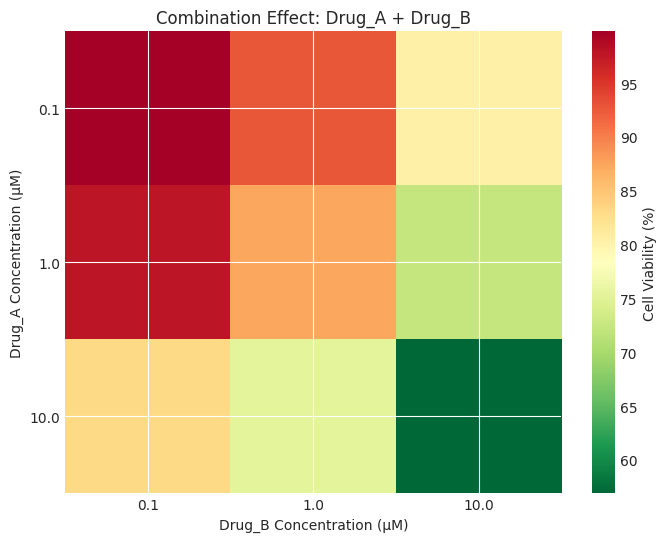

In [5]:
# Visualize as heatmap for the first drug pair
pair_to_plot = drug_pairs[0]
subset = df_combinations[(df_combinations['Drug1'] == pair_to_plot[0]) & 
                         (df_combinations['Drug2'] == pair_to_plot[1])]

# Create pivot table for heatmap
pivot_data = subset.pivot(index='Conc1_µM', columns='Conc2_µM', values='Viability_%')

plt.figure(figsize=(8, 6))
plt.imshow(pivot_data, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
plt.colorbar(label='Cell Viability (%)')
plt.xlabel(f'{pair_to_plot[1]} Concentration (µM)')
plt.ylabel(f'{pair_to_plot[0]} Concentration (µM)')
plt.title(f'Combination Effect: {pair_to_plot[0]} + {pair_to_plot[1]}')
plt.xticks(range(len(pivot_data.columns)), pivot_data.columns)
plt.yticks(range(len(pivot_data.index)), pivot_data.index)
plt.show()

## Example 2: Enzyme Kinetics - Michaelis-Menten Analysis
**Scenario:** Calculate kinetic parameters (Km, Vmax) from experimental data

*Libraries: numpy, pandas, matplotlib*

### Example 2 (numpy focused):
- Michaelis-Menten kinetics
- Lineweaver-Burk transformation
- Parameter estimation (Km, Vmax)
- Curve fitting with confidence

In [6]:
# Load enzyme kinetics data
# Data: Substrate concentration (mM) and reaction velocity (µmol/min/mg)

# Method 1: Create data directly
kinetics_data = {
    'Substrate_mM': [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
    'Velocity': [2.3, 4.1, 8.5, 13.2, 18.9, 23.5, 25.1, 25.8]
}

df_kinetics = pd.DataFrame(kinetics_data)
print("Enzyme Kinetics Data:")
print(df_kinetics)
print(f"\nData shape: {df_kinetics.shape}")
print(f"Substrate range: {df_kinetics['Substrate_mM'].min()} - {df_kinetics['Substrate_mM'].max()} mM")

Enzyme Kinetics Data:
   Substrate_mM  Velocity
0           0.1       2.3
1           0.2       4.1
2           0.5       8.5
3           1.0      13.2
4           2.0      18.9
5           5.0      23.5
6          10.0      25.1
7          20.0      25.8

Data shape: (8, 2)
Substrate range: 0.1 - 20.0 mM


In [7]:
# Michaelis-Menten fit using numpy
from scipy import stats

# Lineweaver-Burk linearization: 1/V = (Km/Vmax)*(1/[S]) + 1/Vmax
df_kinetics['Inverse_Substrate'] = 1 / df_kinetics['Substrate_mM']
df_kinetics['Inverse_Velocity'] = 1 / df_kinetics['Velocity']

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_kinetics['Inverse_Substrate'], 
    df_kinetics['Inverse_Velocity']
)

# Calculate kinetic parameters
Vmax = 1 / intercept
Km = slope * Vmax

print(f"Kinetic Parameters:")
print(f"  Vmax = {Vmax:.2f} µmol/min/mg")
print(f"   Km  = {Km:.2f} mM")
print(f"  R²   = {r_value**2:.4f}")
print(f"\nLineweaver-Burk equation: 1/V = {slope:.3f} * (1/[S]) + {intercept:.3f}")

Kinetic Parameters:
  Vmax = 27.77 µmol/min/mg
   Km  = 1.12 mM
  R²   = 0.9995

Lineweaver-Burk equation: 1/V = 0.040 * (1/[S]) + 0.036


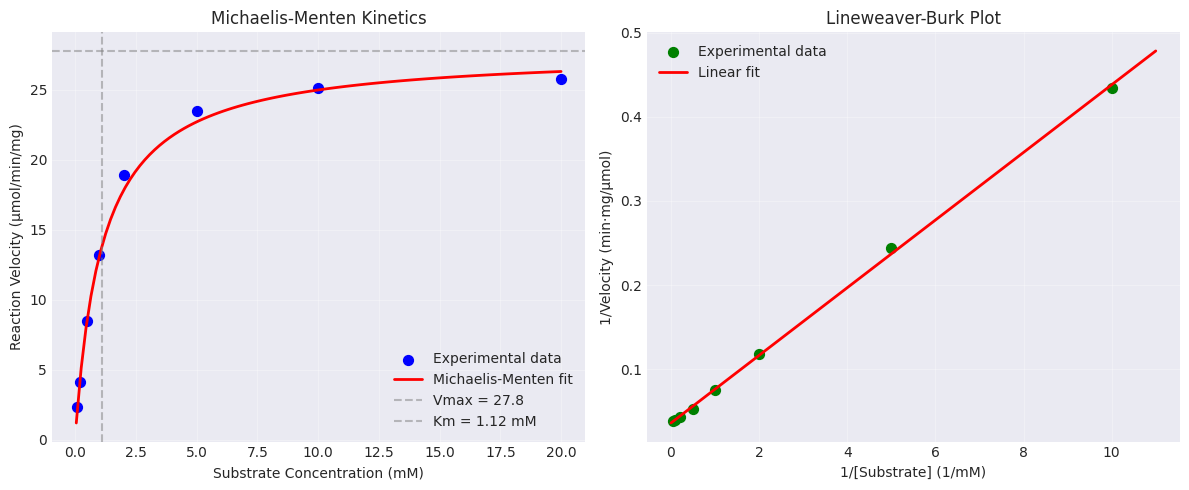

In [8]:
# Generate fitted curve
substrate_fine = np.linspace(0.05, 20, 100)
velocity_fitted = (Vmax * substrate_fine) / (Km + substrate_fine)

# Plot Michaelis-Menten curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Main plot
ax1.scatter(df_kinetics['Substrate_mM'], df_kinetics['Velocity'], 
            color='blue', s=50, label='Experimental data')
ax1.plot(substrate_fine, velocity_fitted, 'r-', linewidth=2, label='Michaelis-Menten fit')
ax1.axhline(Vmax, color='gray', linestyle='--', alpha=0.5, label=f'Vmax = {Vmax:.1f}')
ax1.axvline(Km, color='gray', linestyle='--', alpha=0.5, label=f'Km = {Km:.2f} mM')
ax1.set_xlabel('Substrate Concentration (mM)')
ax1.set_ylabel('Reaction Velocity (µmol/min/mg)')
ax1.set_title('Michaelis-Menten Kinetics')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Lineweaver-Burk plot
ax2.scatter(df_kinetics['Inverse_Substrate'], df_kinetics['Inverse_Velocity'], 
            color='green', s=50, label='Experimental data')
x_line = np.linspace(0, max(df_kinetics['Inverse_Substrate']) + 1, 100)
ax2.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label='Linear fit')
ax2.set_xlabel('1/[Substrate] (1/mM)')
ax2.set_ylabel('1/Velocity (min·mg/µmol)')
ax2.set_title('Lineweaver-Burk Plot')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Example 3: Protein Expression Analysis with Statistics
**Scenario:** Compare protein expression levels between control and treated groups

*Libraries: numpy, pandas, matplotlib*

### Example 3 (pandas focused):
- Protein expression statistics
- Group comparisons (t-test)
- SEM calculation
- Publication-ready plots

In [9]:
# Load protein expression data (simulated)
np.random.seed(123)

n_samples = 12
protein_data = {
    'Sample_ID': [f'Sample_{i}' for i in range(1, n_samples + 1)],
    'Group': ['Control']*6 + ['Treated']*6,
    'Protein_Level': np.concatenate([
        np.random.normal(100, 15, 6),   # Control group
        np.random.normal(150, 20, 6)    # Treated group
    ])
}

df_protein = pd.DataFrame(protein_data)
df_protein['Protein_Level'] = df_protein['Protein_Level'].round(1)
print("Protein Expression Data:")
print(df_protein)
print(f"\nSummary statistics:")
print(df_protein.groupby('Group')['Protein_Level'].describe())

Protein Expression Data:
    Sample_ID    Group  Protein_Level
0    Sample_1  Control           83.7
1    Sample_2  Control          115.0
2    Sample_3  Control          104.2
3    Sample_4  Control           77.4
4    Sample_5  Control           91.3
5    Sample_6  Control          124.8
6    Sample_7  Treated          101.5
7    Sample_8  Treated          141.4
8    Sample_9  Treated          175.3
9   Sample_10  Treated          132.7
10  Sample_11  Treated          136.4
11  Sample_12  Treated          148.1

Summary statistics:
         count        mean        std    min      25%     50%      75%    max
Group                                                                        
Control    6.0   99.400000  18.480584   77.4   85.600   97.75  112.300  124.8
Treated    6.0  139.233333  23.910806  101.5  133.625  138.90  146.425  175.3


In [21]:
# Calculate statistics
control = df_protein[df_protein['Group'] == 'Control']['Protein_Level']
treated = df_protein[df_protein['Group'] == 'Treated']['Protein_Level']

# Basic statistics
mean_control = np.mean(control)
mean_treated = np.mean(treated)
std_control = np.std(control, ddof=1)
std_treated = np.std(treated, ddof=1)
sem_control = std_control / np.sqrt(len(control))
sem_treated = std_treated / np.sqrt(len(treated))

# T-test
from scipy import stats
t_stat, p_value = stats.ttest_ind(control, treated)

# Fold change
fold_change = mean_treated / mean_control

print("Statistical Analysis:")
print(f"  Control:  {mean_control:.1f} ± {sem_control:.1f} (mean ± SEM)")
print(f"  Treated:  {mean_treated:.1f} ± {sem_treated:.1f} (mean ± SEM)")
print(f"  Fold change: {fold_change:.2f}x")
print(f"  T-statistic: {t_stat:.3f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")

Statistical Analysis:
  Control:  99.4 ± 7.5 (mean ± SEM)
  Treated:  139.2 ± 9.8 (mean ± SEM)
  Fold change: 1.40x
  T-statistic: -3.229
  P-value: 0.0090
  Significant: Yes


In [22]:
print(control)

0     83.7
1    115.0
2    104.2
3     77.4
4     91.3
5    124.8
Name: Protein_Level, dtype: float64


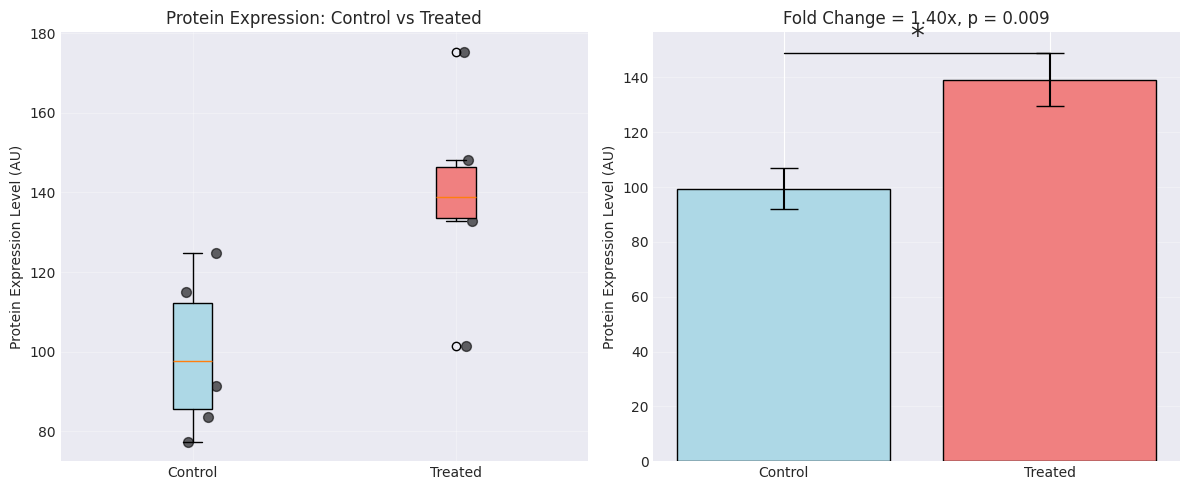

In [11]:
# Create publication-quality plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Box plot with individual points
groups = ['Control', 'Treated']
data_to_plot = [control, treated]

bp = ax1.boxplot(data_to_plot, labels=groups, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

# Add individual points
for i, data in enumerate(data_to_plot, 1):
    x = np.random.normal(i, 0.04, size=len(data))
    ax1.scatter(x, data, alpha=0.6, color='black', s=50)

ax1.set_ylabel('Protein Expression Level (AU)')
ax1.set_title('Protein Expression: Control vs Treated')
ax1.grid(True, alpha=0.3)

# Bar plot with error bars
means = [mean_control, mean_treated]
errors = [sem_control, sem_treated]

bars = ax2.bar(groups, means, yerr=errors, capsize=10, 
               color=['lightblue', 'lightcoral'], edgecolor='black')
ax2.set_ylabel('Protein Expression Level (AU)')
ax2.set_title(f'Fold Change = {fold_change:.2f}x, p = {p_value:.3f}')
ax2.grid(True, alpha=0.3, axis='y')

# Add significance annotation
if p_value < 0.05:
    y_max = max(means) + max(errors)
    ax2.plot([0, 1], [y_max, y_max], 'k-', linewidth=1)
    ax2.text(0.5, y_max + y_max*0.02, '*', ha='center', fontsize=20)

plt.tight_layout()
plt.show()

## Example 4: Dose-Response Curve with IC50 Calculation
**Scenario:** Determine IC50 of an inhibitor from concentration-response data

*Libraries: numpy, pandas, matplotlib*

### Example 4 (matplotlib focused):
- Dose-response curves
- IC50 calculation using Hill equation
- Semi-log plots (standard in pharmacology)
- Parameter interpretation

In [12]:
# Dose-response data
# Inhibitor concentrations and corresponding enzyme activity
dose_data = {
    'Inhibitor_nM': [0, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000],
    'Activity_percent': [100, 92, 78, 65, 48, 35, 18, 12, 5, 2]
}

df_dose = pd.DataFrame(dose_data)
print("Dose-Response Data:")
print(df_dose)
print(f"\nConcentration range: {df_dose['Inhibitor_nM'].min()} - {df_dose['Inhibitor_nM'].max()} nM")

Dose-Response Data:
   Inhibitor_nM  Activity_percent
0           0.0               100
1           0.1                92
2           0.5                78
3           1.0                65
4           5.0                48
5          10.0                35
6          50.0                18
7         100.0                12
8         500.0                 5
9        1000.0                 2

Concentration range: 0.0 - 1000.0 nM


In [13]:
# Fit 4-parameter logistic model
from scipy.optimize import curve_fit

# Define Hill equation: Activity = bottom + (top-bottom) / (1 + (IC50/[I])^Hill)
def hill_equation(conc, bottom, top, ic50, hillslope):
    return bottom + (top - bottom) / (1 + (ic50 / conc) ** hillslope)

# Prepare data (avoid log(0))
x_data = df_dose['Inhibitor_nM'].values
y_data = df_dose['Activity_percent'].values

# Replace 0 with very small value for fitting
x_data_fit = np.where(x_data == 0, 1e-10, x_data)

# Initial guesses: bottom=0, top=100, ic50=10, hillslope=1
popt, pcov = curve_fit(hill_equation, x_data_fit, y_data, 
                       p0=[0, 100, 10, 1], maxfev=5000)

bottom, top, ic50, hillslope = popt

print(f"Fitted Parameters:")
print(f"  Bottom (min activity): {bottom:.1f}%")
print(f"  Top (max activity): {top:.1f}%")
print(f"  IC50: {ic50:.2f} nM")
print(f"  Hill slope: {hillslope:.2f}")
print(f"\nInterpretation: The inhibitor concentration that reduces activity by 50% is {ic50:.2f} nM")

Fitted Parameters:
  Bottom (min activity): 100.9%
  Top (max activity): -1.1%
  IC50: 3.79 nM
  Hill slope: 0.58

Interpretation: The inhibitor concentration that reduces activity by 50% is 3.79 nM


/tmp/ipykernel_11683/2793791788.py:6: RuntimeWarning: invalid value encountered in power
  return bottom + (top - bottom) / (1 + (ic50 / conc) ** hillslope)


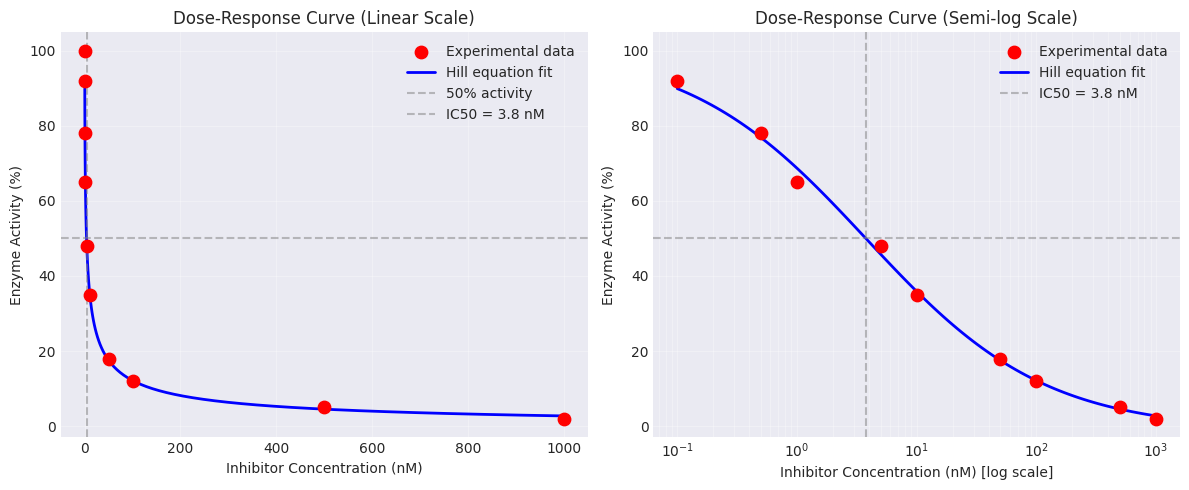

In [14]:
# Generate smooth curve for plotting
x_smooth = np.logspace(-1, 3, 100)  # from 0.1 to 1000 nM
y_smooth = hill_equation(x_smooth, *popt)

# Create plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale
ax1.scatter(df_dose['Inhibitor_nM'], df_dose['Activity_percent'], 
            color='red', s=80, label='Experimental data', zorder=5)
ax1.plot(x_smooth, y_smooth, 'b-', linewidth=2, label='Hill equation fit')
ax1.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% activity')
ax1.axvline(ic50, color='gray', linestyle='--', alpha=0.5, label=f'IC50 = {ic50:.1f} nM')
ax1.set_xlabel('Inhibitor Concentration (nM)')
ax1.set_ylabel('Enzyme Activity (%)')
ax1.set_title('Dose-Response Curve (Linear Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale (more common for IC50 plots)
ax2.scatter(df_dose['Inhibitor_nM'], df_dose['Activity_percent'], 
            color='red', s=80, label='Experimental data', zorder=5)
ax2.semilogx(x_smooth, y_smooth, 'b-', linewidth=2, label='Hill equation fit')
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(ic50, color='gray', linestyle='--', alpha=0.5, label=f'IC50 = {ic50:.1f} nM')
ax2.set_xlabel('Inhibitor Concentration (nM) [log scale]')
ax2.set_ylabel('Enzyme Activity (%)')
ax2.set_title('Dose-Response Curve (Semi-log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Example 5: Time-Course Analysis of Metabolite Concentrations
**Scenario:** Track metabolite changes over time under different conditions

*Libraries: pandas, numpy, matplotlib*

In [15]:
# Load time-course metabolomics data
np.random.seed(456)

time_points = [0, 15, 30, 60, 120, 180]  # minutes
metabolites = ['Glucose', 'Lactate', 'ATP', 'NADH']

# Simulate data with different patterns
data = []
for time in time_points:
    for metabolite in metabolites:
        if metabolite == 'Glucose':
            value = 10 * np.exp(-0.02 * time) + np.random.normal(0, 0.3)
        elif metabolite == 'Lactate':
            value = 2 * (1 - np.exp(-0.015 * time)) + np.random.normal(0, 0.2)
        elif metabolite == 'ATP':
            value = 5 * np.exp(-0.001 * time) + np.random.normal(0, 0.1)
        else:  # NADH
            value = 1 + 0.5 * np.sin(time/30) + np.random.normal(0, 0.1)
        
        data.append({
            'Time_min': time,
            'Metabolite': metabolite,
            'Concentration_mM': round(max(0, value), 2)
        })

df_metabolites = pd.DataFrame(data)
print("Metabolite Time-Course Data:")
print(df_metabolites.head(10))
print(f"\nShape: {df_metabolites.shape}")
print(f"Time points: {df_metabolites['Time_min'].unique()}")
print(f"Metabolites: {df_metabolites['Metabolite'].unique()}")

Metabolite Time-Course Data:
   Time_min Metabolite  Concentration_mM
0         0    Glucose              9.80
1         0    Lactate              0.00
2         0        ATP              5.06
3         0       NADH              1.06
4        15    Glucose              7.81
5        15    Lactate              0.73
6        15        ATP              4.96
7        15       NADH              1.28
8        30    Glucose              5.38
9        30    Lactate              0.66

Shape: (24, 3)
Time points: [  0  15  30  60 120 180]
Metabolites: ['Glucose' 'Lactate' 'ATP' 'NADH']


In [16]:
# Calculate summary statistics
summary = df_metabolites.groupby(['Metabolite', 'Time_min'])['Concentration_mM'].agg(['mean', 'std', 'sem'])
summary.columns = ['Mean', 'Std', 'SEM']
print("Summary Statistics (Mean ± SEM):")
print(summary.head(10))

# Calculate fold change from time 0
df_metabolites_pivot = df_metabolites.pivot(index='Time_min', columns='Metabolite', values='Concentration_mM')
fold_changes = df_metabolites_pivot / df_metabolites_pivot.iloc[0]
print("\nFold Change from Time 0:")
print(fold_changes.round(2))

Summary Statistics (Mean ± SEM):
                     Mean  Std  SEM
Metabolite Time_min                
ATP        0         5.06  NaN  NaN
           15        4.96  NaN  NaN
           30        4.65  NaN  NaN
           60        4.68  NaN  NaN
           120       4.53  NaN  NaN
           180       4.08  NaN  NaN
Glucose    0         9.80  NaN  NaN
           15        7.81  NaN  NaN
           30        5.38  NaN  NaN
           60        2.68  NaN  NaN

Fold Change from Time 0:
Metabolite   ATP  Glucose  Lactate  NADH
Time_min                                
0           1.00     1.00      NaN  1.00
15          0.98     0.80      inf  1.21
30          0.92     0.55      inf  1.24
60          0.92     0.27      inf  1.56
120         0.90     0.15      inf  0.70
180         0.81     0.02      inf  0.77


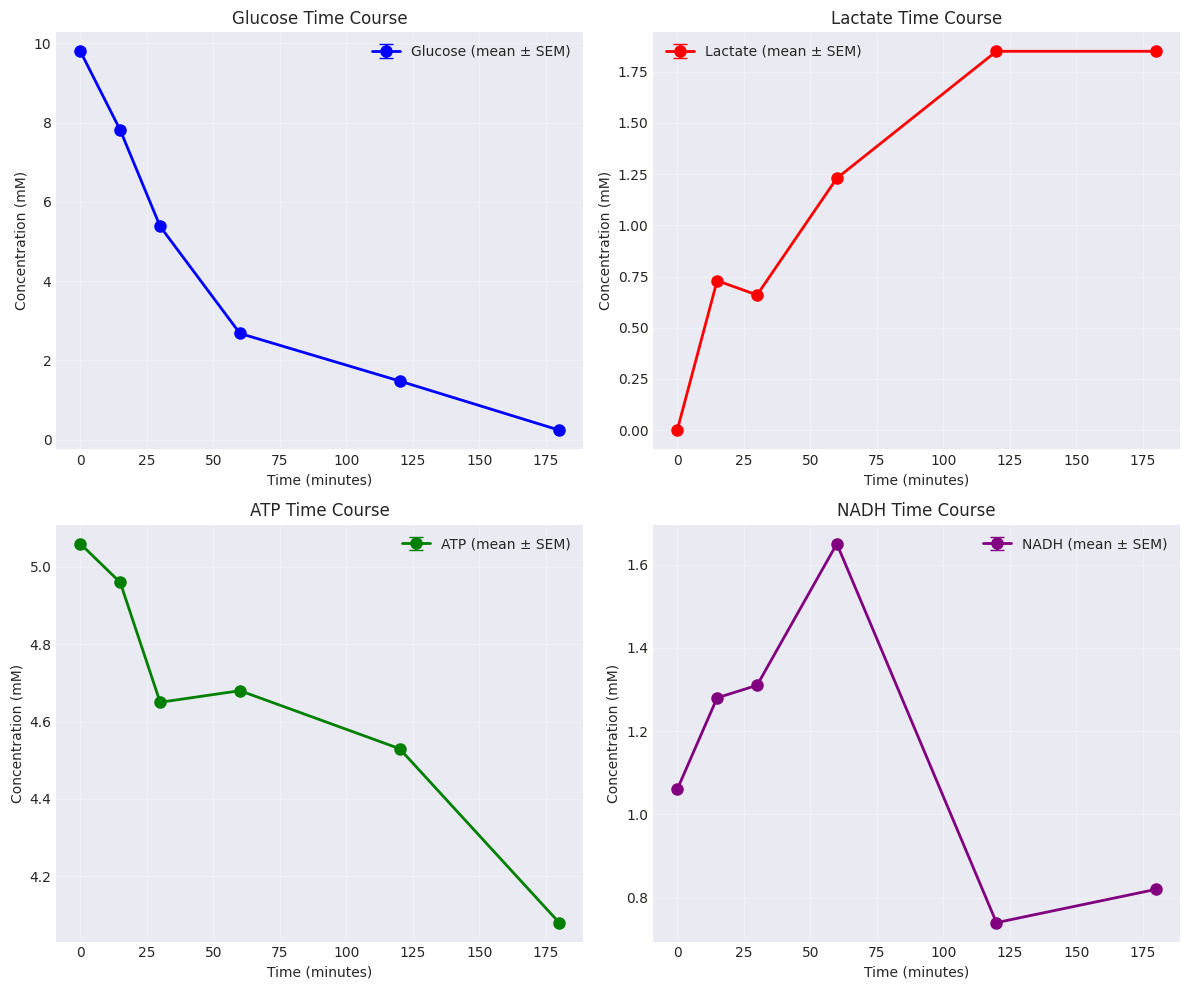

In [17]:
# Create multi-panel time-course plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

colors = ['blue', 'red', 'green', 'purple']

for idx, metabolite in enumerate(metabolites):
    subset = df_metabolites[df_metabolites['Metabolite'] == metabolite]
    
    # Calculate mean and SEM for each time point
    time_stats = subset.groupby('Time_min')['Concentration_mM'].agg(['mean', 'sem']).reset_index()
    
    axes[idx].errorbar(time_stats['Time_min'], time_stats['mean'], 
                       yerr=time_stats['sem'], fmt='o-', 
                       color=colors[idx], capsize=5, 
                       markersize=8, linewidth=2, 
                       label=f'{metabolite} (mean ± SEM)')
    
    # Add individual points
    axes[idx].scatter(subset['Time_min'], subset['Concentration_mM'], 
                      alpha=0.3, color=colors[idx], s=30)
    
    axes[idx].set_xlabel('Time (minutes)')
    axes[idx].set_ylabel('Concentration (mM)')
    axes[idx].set_title(f'{metabolite} Time Course')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Area Under Curve (AUC) Analysis:
  Metabolite     AUC
0    Glucose  528.30
1    Lactate  247.65
2        ATP  821.77
3       NADH  199.88


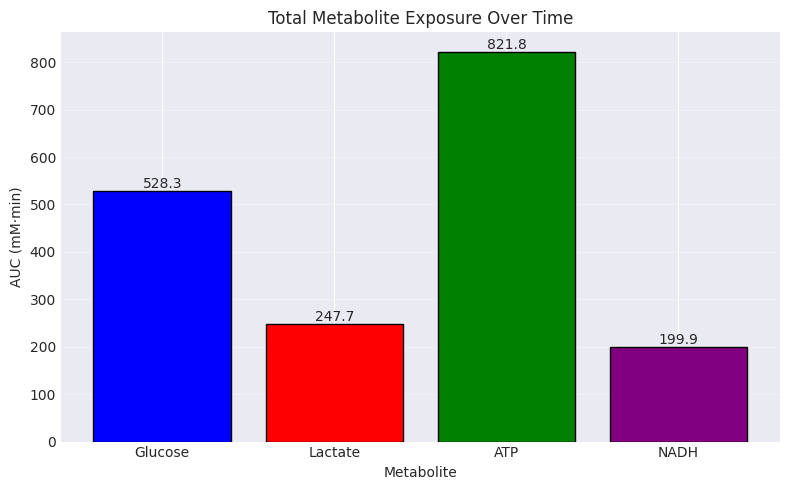

In [18]:
# Area under curve (AUC) calculation
from scipy.integrate import trapz

auc_results = []
for metabolite in metabolites:
    subset = df_metabolites[df_metabolites['Metabolite'] == metabolite]
    time_points = subset['Time_min'].unique()
    
    # Calculate mean at each time point
    mean_values = subset.groupby('Time_min')['Concentration_mM'].mean().values
    
    # Calculate AUC using trapezoidal rule
    auc = trapz(mean_values, time_points)
    auc_results.append({'Metabolite': metabolite, 'AUC': round(auc, 2)})

df_auc = pd.DataFrame(auc_results)
print("Area Under Curve (AUC) Analysis:")
print(df_auc)

# Create AUC bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(df_auc['Metabolite'], df_auc['AUC'], 
               color=['blue', 'red', 'green', 'purple'], 
               edgecolor='black')
plt.xlabel('Metabolite')
plt.ylabel('AUC (mM·min)')
plt.title('Total Metabolite Exposure Over Time')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Bonus: Export Data for Further Analysis

Save your processed data to files

In [19]:
# Export key datasets
df_kinetics.to_csv('enzyme_kinetics_data.csv', index=False)
df_protein.to_csv('protein_expression_data.csv', index=False)
df_dose.to_csv('dose_response_data.csv', index=False)
df_metabolites.to_csv('metabolite_timecourse.csv', index=False)

print("Data exported to CSV files:")
print("  - enzyme_kinetics_data.csv")
print("  - protein_expression_data.csv")
print("  - dose_response_data.csv")
print("  - metabolite_timecourse.csv")

# Create a summary report
with open('analysis_summary.txt', 'w') as f:
    f.write("BIOCHEMISTRY DATA ANALYSIS SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Enzyme Kinetics: Vmax = {Vmax:.2f}, Km = {Km:.2f}\n")
    f.write(f"Protein Expression: Fold change = {fold_change:.2f}, p = {p_value:.4f}\n")
    f.write(f"IC50 Value: {ic50:.2f} nM\n")
    f.write(f"Metabolites analyzed: {len(metabolites)}\n")

print("\nSummary report saved to: analysis_summary.txt")

# Display first few lines of summary
print("\n" + "="*50)
with open('analysis_summary.txt', 'r') as f:
    print(f.read())

Data exported to CSV files:
  - enzyme_kinetics_data.csv
  - protein_expression_data.csv
  - dose_response_data.csv
  - metabolite_timecourse.csv

Summary report saved to: analysis_summary.txt

BIOCHEMISTRY DATA ANALYSIS SUMMARY

Enzyme Kinetics: Vmax = 27.77, Km = 1.12
Protein Expression: Fold change = 1.40, p = 0.0090
IC50 Value: 3.79 nM
Metabolites analyzed: 4

